# Support Vector Machine (SVM): Hard Margin, Soft Margin, Slack (xi) and C

Goal of this notebook: understand SVM by looking at real numbers, not just formulas.

What we will do:
- Load a small dataset (`svm_data.csv`) with two features `x1`, `x2` and a `class` label
- Understand the **score** `f(x)` and the **decision boundary**
- Understand why the margin lines are **+1** and **-1**
- Understand **slack (xi)** and calculate it by hand
- Train a real SVM with scikit-learn and verify our hand calculations
- See what **C** does

## 1. Load the data

- `x1`, `x2` : the two input features (think: two exam scores)
- `class` : 1 = Pass, 0 = Fail
- The dataset has a few **outliers** on purpose (points sitting on the wrong side). This is where soft margin becomes useful.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("svm_data.csv")
print(df.shape)
df.head(10)

(84, 3)


,x1,x2,class
0,3.26,2.61,0
1,6.99,5.71,1
2,7.59,6.81,1
3,3.05,2.90,0
4,5.00,4.20,1
5,7.29,6.15,1
6,4.62,3.25,0
7,2.94,3.71,0
8,8.37,7.37,1
9,8.59,5.25,1


In [2]:
print(df["class"].value_counts())
df.describe()

class
0    42
1    42
Name: count, dtype: int64


,x1,x2,class
count,84.000000,84.000000,84.000000
mean,5.426905,5.382024,0.500000
std,2.165943,2.154510,0.503003
min,0.960000,1.810000,0.000000
25%,3.705000,3.680000,0.000000
50%,5.200000,5.125000,0.500000
75%,7.032500,7.195000,1.000000
max,10.100000,11.290000,1.000000


## 2. Visualize the data

Always look at the data first. Here we ask one question: can a straight line separate the two classes?

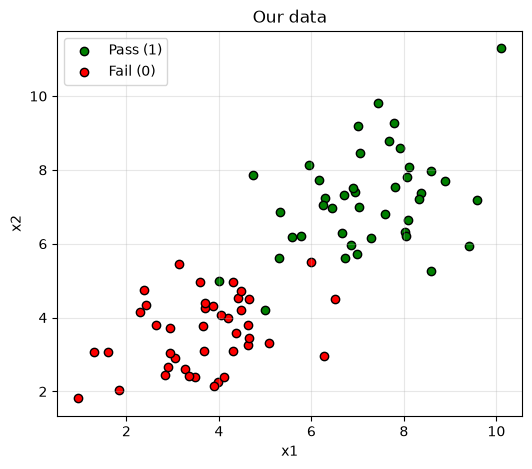

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(df[df["class"]==1]["x1"], df[df["class"]==1]["x2"], c="green", label="Pass (1)", edgecolors="k")
plt.scatter(df[df["class"]==0]["x1"], df[df["class"]==0]["x2"], c="red", label="Fail (0)", edgecolors="k")
plt.xlabel("x1"); plt.ylabel("x2"); plt.title("Our data")
plt.legend(); plt.grid(alpha=0.3); plt.show()

Observation:
- Most points are cleanly separated.
- A few points are mixed near the middle. No perfect straight line can separate all of them.
- So a **hard margin** SVM will struggle, and a **soft margin** SVM is the right tool.

## 3. Step 1: Decision boundary and score

Suppose SVM finds this line:

`x1 + x2 - 10 = 0`

For every point, SVM computes a **score**:

`f(x) = x1 + x2 - 10`

- Score = 0 : point is exactly on the boundary
- Score > 0 : Pass side
- Score < 0 : Fail side
- Bigger absolute score : point is further from the boundary (more confident)

In [4]:
def score(x1, x2):
    return x1 + x2 - 10

print("Point (8, 7) ->", score(8, 7))
print("Point (2, 3) ->", score(2, 3))
print("Point (5, 5) ->", score(5, 5), "(exactly on the boundary)")

Point (8, 7) -> 5
Point (2, 3) -> -5
Point (5, 5) -> 0 (exactly on the boundary)


## 4. Step 2: Why we need a margin

A point with score `+0.1` is technically Pass, but it is extremely close to the boundary.
A little noise can push it to `-0.1` and it becomes Fail.

So SVM says: **do not just separate the classes, keep a safe gap from the boundary.**

## 5. Step 3: Where do +1 and -1 come from?

SVM **chooses** them. They are not found in nature.

- SVM could have chosen +10 and -10, or +100 and -100
- It picks **+1 and -1** only because the math becomes simple

The rule:
- Pass students should have score **at least +1**
- Fail students should have score **at most -1**

The three important lines:
- `f(x) = +1` : upper margin line
- `f(x) = 0` : decision boundary
- `f(x) = -1` : lower margin line

## 6. Step 4: Hard margin constraint

To write both rules in one line, we convert labels to **+1 (Pass)** and **-1 (Fail)**. Call this `y`.

`y * f(x) >= 1`

- Pass point (y = +1) with score 1.5 : 1 * 1.5 = 1.5 >= 1, satisfied
- Pass point (y = +1) with score 0.5 : 0.5 < 1, violated (inside the margin)
- Fail point (y = -1) with score -1.5 : (-1) * (-1.5) = 1.5 >= 1, satisfied

Hard margin means: **zero violations allowed.** This only works if the data is perfectly separable.

## 7. Step 5 and 6: Soft margin and slack (xi)

Now an outlier arrives. A Pass student has score `0.7`. The hard rule wanted `>= 1`, so it breaks.

Soft margin says: allow a small relaxation. That relaxation is called **xi** (slack).

`y * f(x) >= 1 - xi`

With `xi = 0.3`, the rule becomes `score >= 0.7`, and our student passes the rule.

**Formula to calculate xi for any point:**

`xi = max(0, 1 - y * f(x))`

Important points:
- xi does **not** move the line. It is only a **report card** that says how much this point breaks the margin rule.
- xi = 0 : point is safe (outside or on the margin)
- 0 < xi <= 1 : point is inside the margin but still on the correct side
- xi > 1 : point is on the **wrong side** (misclassified)

## 8. Hand practice: calculate xi manually

Take a Pass point (y = +1) with different scores. Calculate xi yourself before running the cell.

In [ ]:
scores = [1.2, 0.7, 0.2, -0.4]
y_true = +1   # Pass

rows = []
for s in scores:
    xi = max(0, 1 - y_true * s)
    if xi == 0:
        status = "Safe (outside margin)"
    elif xi <= 1:
        status = "Inside margin, correct side"
    else:
        status = "Wrong side (misclassified)"
    rows.append({"score f(x)": s, "1 - y*f(x)": round(1 - y_true*s, 2), "xi": round(xi, 2), "status": status})

pd.DataFrame(rows)

Read the table:
- score 1.2 : xi = 0, no violation
- score 0.7 : xi = 0.3, small violation
- score 0.2 : xi = 0.8, big violation but still on the correct side
- score -0.4 : xi = 1.4, crossed the boundary, so misclassified

## 9. What does C do?

- **xi** = how much a point violates the rule (the report card)
- **C** = how seriously the principal treats each violation

SVM minimizes:

`(1/2) * ||w||^2  +  C * (sum of all xi)`

- **Small C** : principal is relaxed. Wide margin, more violations allowed. Simpler model (may underfit).
- **Large C** : principal is strict. Narrow margin, few violations allowed. Complex model (may overfit).

## 10. Train a real SVM

We split the data into train and test sets, then fit a **linear** SVM using scikit-learn.

In [ ]:
X = df[["x1", "x2"]].values
y01 = df["class"].values
y_pm = np.where(y01 == 1, 1, -1)   # convert 0/1 to -1/+1 for the math

X_train, X_test, y_train, y_test = train_test_split(
    X, y_pm, test_size=0.25, random_state=42, stratify=y_pm
)

model = SVC(kernel="linear", C=1.0)
model.fit(X_train, y_train)

print("Train accuracy:", round(model.score(X_train, y_train), 3))
print("Test accuracy :", round(model.score(X_test, y_test), 3))

## 11. Look inside the model: w and b

The learned boundary is `w1*x1 + w2*x2 + b = 0`. Let us print `w` and `b`, and check that `f(x)` really is the score we discussed.

In [ ]:
w = model.coef_[0]
b = model.intercept_[0]
print("w =", w.round(3))
print("b =", round(b, 3))
print(f"Boundary: {w[0]:.3f}*x1 + {w[1]:.3f}*x2 + {b:.3f} = 0")

# Manual score vs sklearn score
manual = X_test @ w + b
sk = model.decision_function(X_test)
print("Manual score equals sklearn score:", np.allclose(manual, sk))

## 12. Calculate xi for every training point

We use the same formula from section 7: `xi = max(0, 1 - y * f(x))`.

In [ ]:
train_scores = model.decision_function(X_train)
xi = np.maximum(0, 1 - y_train * train_scores)

res = pd.DataFrame({
    "x1": X_train[:, 0],
    "x2": X_train[:, 1],
    "y (+1/-1)": y_train,
    "score f(x)": train_scores.round(3),
    "xi": xi.round(3),
})

def status(x):
    if x == 0: return "safe"
    if x <= 1: return "inside margin"
    return "misclassified"

res["status"] = res["xi"].apply(status)
print(res["status"].value_counts())
res.sort_values("xi", ascending=False).head(10)

The points at the top of this table are the troublemakers. They have the highest xi.
Points with xi = 0 are safe and do not affect the final line at all.

## 13. Plot: boundary, margin lines and support vectors

- Solid line : decision boundary (score = 0)
- Dashed lines : margin lines (score = +1 and score = -1)
- Circled points : **support vectors**. These are the points on or inside the margin, or misclassified. Only these points decide the final line.

In [ ]:
def plot_svm(model, X, y, title):
    w = model.coef_[0]; b = model.intercept_[0]
    plt.figure(figsize=(7, 6))
    plt.scatter(X[y==1, 0], X[y==1, 1], c="green", edgecolors="k", label="Pass (+1)")
    plt.scatter(X[y==-1, 0], X[y==-1, 1], c="red", edgecolors="k", label="Fail (-1)")
    sv = model.support_vectors_
    plt.scatter(sv[:, 0], sv[:, 1], s=200, facecolors="none", edgecolors="blue", linewidths=1.5, label="Support vectors")

    xs = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
    for level, style, lab in [(0, "-", "Boundary (0)"), (1, "--", "+1 margin"), (-1, "--", "-1 margin")]:
        ys = (level - b - w[0] * xs) / w[1]
        plt.plot(xs, ys, "k" + style, label=lab)

    plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
    plt.xlabel("x1"); plt.ylabel("x2"); plt.title(title)
    plt.legend(loc="upper right"); plt.grid(alpha=0.3); plt.show()

plot_svm(model, X_train, y_train, "Soft margin SVM (C = 1)")
print("Number of support vectors:", len(model.support_vectors_))

## 14. Effect of C

We train the same model with three values of C and compare:
- **Margin width** = `2 / ||w||` (bigger is a wider street)
- **Support vectors** = how many points touch or violate the margin
- **Total slack** = sum of all xi (total rule breaking)

In [ ]:
rows = []
models = {}
for c in [0.01, 1, 100]:
    m = SVC(kernel="linear", C=c).fit(X_train, y_train)
    models[c] = m
    ww = m.coef_[0]
    sc = m.decision_function(X_train)
    total_xi = np.maximum(0, 1 - y_train * sc).sum()
    rows.append({
        "C": c,
        "margin width": round(2 / np.linalg.norm(ww), 3),
        "support vectors": len(m.support_vectors_),
        "total slack (sum xi)": round(total_xi, 3),
        "train acc": round(m.score(X_train, y_train), 3),
        "test acc": round(m.score(X_test, y_test), 3),
    })
pd.DataFrame(rows)

In [ ]:
for c, m in models.items():
    plot_svm(m, X_train, y_train, f"C = {c}")

What to notice:
- **C = 0.01** : very wide margin, many support vectors, large total slack. The model tolerates violations.
- **C = 100** : narrow margin, fewer support vectors, small total slack. The model punishes violations heavily.
- **C = 1** : usually a balanced middle ground.

Rule of thumb: choose C using cross-validation, not by guessing.

## 15. Evaluate on the test set

In [ ]:
y_pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print()
print("Confusion matrix (rows = actual, columns = predicted)")
print(pd.DataFrame(confusion_matrix(y_test, y_pred, labels=[-1, 1]),
                   index=["actual Fail", "actual Pass"],
                   columns=["pred Fail", "pred Pass"]))
print()
print(classification_report(y_test, y_pred, target_names=["Fail", "Pass"]))

## 16. Predict for a new student

In [ ]:
new_students = np.array([[8.0, 7.5], [2.5, 3.0], [5.0, 5.0]])
scores_new = model.decision_function(new_students)
preds = model.predict(new_students)

pd.DataFrame({
    "x1": new_students[:, 0],
    "x2": new_students[:, 1],
    "score f(x)": scores_new.round(3),
    "prediction": np.where(preds == 1, "Pass", "Fail"),
})

## 17. Summary

- **Score** `f(x) = w.x + b` : signed distance-like number. Sign gives the class, size gives confidence.
- **Margin lines +1 / -1** : chosen by SVM for mathematical convenience.
- **Hard margin** : `y * f(x) >= 1` for every point. No violations allowed.
- **Soft margin** : `y * f(x) >= 1 - xi`. Small violations allowed.
- **xi** : report card of each point. `xi = max(0, 1 - y * f(x))`. It does not move the line.
- **C** : penalty strength for the total slack. Small C means a wide, forgiving margin. Large C means a narrow, strict margin.
- **Support vectors** : only points on or inside the margin (or misclassified) decide the final line.

Next steps to try:
- Change the outliers in the CSV and watch xi change
- Try `kernel="rbf"` and compare with the linear kernel
- Use `GridSearchCV` to find the best C